# Transformer Machine Translation: English → Russian

Обучение трансформера на задаче перевода с использованием torch.nn.Transformer и датасета WMT19.

## 1. Импорт библиотек и настройка

In [ ]:
import os
import random
import math
import time
from collections import Counter
from typing import List, Tuple, Dict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from datasets import load_dataset
from transformers import AutoTokenizer

from tqdm import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'mps')
print(f"Using device: {device}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cuda
GPU: Tesla T4


## 2. Конфигурация модели и обучения

In [ ]:
config = {
    # Данные
    'src_lang': 'en',  # исходный язык
    'tgt_lang': 'ru',  # целевой язык
    'max_length': 64,
    'train_samples': 10000,
    'val_samples': 10000,
    'test_samples': 1000,

    # Токенизация
    'tokenizer_name': 'Helsinki-NLP/opus-mt-en-ru',
    'vocab_size': 50000,

    # Модель (уменьшена для экономии памяти)
    'd_model': 512,
    'nhead': 8,
    'num_encoder_layers': 6,
    'num_decoder_layers': 6,
    'dim_feedforward': 2048,
    'dropout': 0.2,

    # Обучение
    'batch_size': 8,
    'learning_rate': 1.0,
    'num_epochs': 20,
    'warmup_steps': 2000,
    'grad_clip': 1.0,
    'weight_decay': 0.0001,
    'label_smoothing': 0.1,

    # Генерация
    'max_gen_length': 64,
    'beam_size': 1,
    'temperature': 0.6,
}

print("Configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

Configuration:
  src_lang: en
  tgt_lang: ru
  max_length: 64
  train_samples: 10000
  val_samples: 10000
  test_samples: 1000
  tokenizer_name: Helsinki-NLP/opus-mt-en-ru
  vocab_size: 50000
  d_model: 512
  nhead: 8
  num_encoder_layers: 6
  num_decoder_layers: 6
  dim_feedforward: 2048
  dropout: 0.2
  batch_size: 8
  learning_rate: 1.0
  num_epochs: 20
  warmup_steps: 2000
  grad_clip: 1.0
  weight_decay: 0.0001
  label_smoothing: 0.1
  max_gen_length: 64
  beam_size: 1
  temperature: 0.6


## 3. Загрузка датасета

In [ ]:
def load_opus_data(config):
  """Загружает и подготавливает данные Opus Books для перевода en->ru"""
  print("Loading Opus Books dataset...")

  try:
      dataset = load_dataset(
          "opus_books",
          "en-ru"
      )
      print(f"Dataset loaded: {dataset}")
      if 'validation' not in dataset and 'test' not in dataset:
          print("Creating validation and test splits from train data...")
          train_val_test = dataset['train'].train_test_split(test_size=0.1, seed=42)
          val_test = train_val_test['test'].train_test_split(test_size=0.5, seed=42)

          dataset['train'] = train_val_test['train']
          dataset['validation'] = val_test['train']
          dataset['test'] = val_test['test']
          print(f"Train: {len(dataset['train'])}, Val: {len(dataset['validation'])}, Test: {len(dataset['test'])}")

      return dataset
  except Exception as e:
      print(f"Error loading Opus Books: {e}")
      return None

dataset = load_opus_data(config)

Loading Opus Books dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-ru/train-00000-of-00001.parquet:   0%|          | 0.00/2.92M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/17496 [00:00<?, ? examples/s]

Dataset loaded: DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 17496
    })
})
Creating validation and test splits from train data...
Train: 15746, Val: 875, Test: 875


In [ ]:
print("Dataset splits:")
for split in dataset.keys():
    print(f"  {split}: {len(dataset[split])} samples")

print("\nSample from train set:")
print(dataset['train'][1])

Dataset splits:
  train: 15746 samples
  validation: 875 samples
  test: 875 samples

Sample from train set:
{'id': '14392', 'translation': {'en': 'His farming calculations that there is a price below which certain grain must not be sold were forgotten too.', 'ru': 'Расчет хозяйственный о том, что есть известная цена, ниже которой нельзя продать известный хлеб, тоже был забыт.'}}


## 4. Подготовка токенизатора

In [ ]:
!pip install sacremoses

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 57.6 MB/s eta 0:00:00


In [ ]:
def prepare_tokenizers(config):
    """Подготавливает токенизаторы для исходного и целевого языков"""
    print("Loading tokenizers...")
    tokenizer_name = 'Helsinki-NLP/opus-mt-en-ru'

    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    print(f"Loaded tokenizer: {tokenizer_name}")

    config['vocab_size'] = len(tokenizer)
    config['pad_token_id'] = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    if tokenizer.bos_token_id is None:
      config['bos_token_id'] = tokenizer.eos_token_id
    else:
      config['bos_token_id'] = tokenizer.bos_token_id
    config['eos_token_id'] = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else 2

    print(f"Vocabulary size: {config['vocab_size']}")
    print(f"Special tokens: PAD={config['pad_token_id']}, EOS={config['eos_token_id']}, BOS={config['bos_token_id']}")

    return tokenizer

tokenizer = prepare_tokenizers(config)

Loading tokenizers...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/803k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Loaded tokenizer: Helsinki-NLP/opus-mt-en-ru
Vocabulary size: 62518
Special tokens: PAD=62517, EOS=0, BOS=0


## 5. Класс Dataset для перевода

In [ ]:
class TranslationDataset(Dataset):
    """Dataset для задачи машинного перевода (готовый к Transformer)"""

    def __init__(
        self,
        dataset,
        tokenizer,
        max_length,
        src_lang='en',
        tgt_lang='ru',
        num_samples=None,
        split='train',
        filter_by_length=False,
        bos_token_id=None
    ):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang
        self.filter_by_length = filter_by_length
        self.bos_token_id = bos_token_id

        self.data = self._prepare_data(dataset, num_samples, split)

    def _prepare_data(self, dataset, num_samples, split):
        data = []
        limit = num_samples if num_samples is not None else len(dataset)

        for i, item in enumerate(dataset):
            if i >= limit:
                break

            if 'translation' in item:
                src_text = item['translation'].get(self.src_lang)
                tgt_text = item['translation'].get(self.tgt_lang)
            else:
                src_text = item.get(self.src_lang)
                tgt_text = item.get(self.tgt_lang)

            if not src_text or not tgt_text:
                continue

            src_text = src_text.strip()
            tgt_text = tgt_text.strip()

            if len(src_text) == 0 or len(tgt_text) == 0:
                continue

            data.append({'src': src_text, 'tgt': tgt_text})

        if self.filter_by_length:
            filtered = []
            for item in data:
                src_ids = self.tokenizer(
                    item['src'],
                    truncation=True,
                    max_length=self.max_length
                )['input_ids']

                tgt_ids = self.tokenizer(
                    item['tgt'],
                    truncation=True,
                    max_length=self.max_length
                )['input_ids']

                if len(src_ids) < self.max_length and len(tgt_ids) < self.max_length:
                    filtered.append(item)

            print(f"{split}: filtered {len(data) - len(filtered)} samples")
            data = filtered

        print(f"{split}: {len(data)} samples")
        return data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # --- SOURCE ---
        src = self.tokenizer(
            item['src'],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        tgt = self.tokenizer(
            item['tgt'],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        src_ids = src['input_ids'].squeeze(0)
        src_mask = src['attention_mask'].squeeze(0)

        tgt_ids = tgt['input_ids'].squeeze(0)
        tgt_mask = tgt['attention_mask'].squeeze(0)

        tgt_input = torch.cat([
            torch.tensor([self.bos_token_id], dtype=torch.long),
            tgt_ids[:-1]
        ])

        tgt_output = tgt_ids

        return {
            'src_ids': src_ids,
            'src_mask': src_mask,
            'tgt_input': tgt_input,
            'tgt_output': tgt_output,
            'tgt_mask': tgt_mask,
            'src_text': item['src'],
            'tgt_text': item['tgt']
        }

In [ ]:
train_dataset = TranslationDataset(
    dataset['train'],
    tokenizer,
    max_length=config['max_length'],
    src_lang=config['src_lang'],
    tgt_lang=config['tgt_lang'],
    num_samples=config['train_samples'],
    split='train',
    filter_by_length=True,
    bos_token_id=config['bos_token_id']
)

val_dataset = TranslationDataset(
    dataset['validation'],
    tokenizer,
    max_length=config['max_length'],
    src_lang=config['src_lang'],
    tgt_lang=config['tgt_lang'],
    num_samples=config['val_samples'],
    split='validation',
    filter_by_length=True,
    bos_token_id=config['bos_token_id']
)

test_dataset = TranslationDataset(
    dataset['test'],
    tokenizer,
    max_length=config['max_length'],
    src_lang=config['src_lang'],
    tgt_lang=config['tgt_lang'],
    num_samples=config['test_samples'],
    split='test',
    filter_by_length=True,
    bos_token_id=config['bos_token_id']
)

train: filtered 5712 samples
train: 4288 samples
validation: filtered 529 samples
validation: 346 samples
test: filtered 501 samples
test: 374 samples


In [ ]:
sample = train_dataset[0]

print("\n--- Sample Example ---")
print(f"EN: {sample['src_text']}")
print(f"RU: {sample['tgt_text']}")

print("\nShapes:")
print("src_ids:", sample['src_ids'].shape)
print("tgt_input:", sample['tgt_input'].shape)
print("tgt_output:", sample['tgt_output'].shape)

print("\nDecoded check:")
print("SRC:", tokenizer.decode(sample['src_ids'], skip_special_tokens=True))
print("TGT:", tokenizer.decode(sample['tgt_output'], skip_special_tokens=True))


--- Sample Example ---
EN: She thought with wonder of her state the day before.
RU: Она с удивлением вспомнила свое вчерашнее состояние.

Shapes:
src_ids: torch.Size([64])
tgt_input: torch.Size([64])
tgt_output: torch.Size([64])

Decoded check:
SRC: She thought with wonder of her state the day before.
TGT: Она с удивлением вспомнила свое вчерашнее состояние.


## 6. Создание DataLoader

In [ ]:
def collate_fn(batch):
    """Правильный collate_fn для Transformer"""

    src_ids = torch.stack([item['src_ids'] for item in batch])
    src_mask = torch.stack([item['src_mask'] for item in batch])

    tgt_input = torch.stack([item['tgt_input'] for item in batch])
    tgt_output = torch.stack([item['tgt_output'] for item in batch])
    tgt_mask = torch.stack([item['tgt_mask'] for item in batch])

    src_key_padding_mask = (src_ids == config['pad_token_id'])
    tgt_key_padding_mask = (tgt_input == config['pad_token_id'])
    seq_len = tgt_input.size(1)

    tgt_attention_mask = torch.triu(
        torch.ones(seq_len, seq_len) * float('-inf'),
        diagonal=1
    )

    return {
        'src_ids': src_ids,
        'tgt_input': tgt_input,
        'tgt_output': tgt_output,

        'src_key_padding_mask': src_key_padding_mask,
        'tgt_key_padding_mask': tgt_key_padding_mask,
        'tgt_attention_mask': tgt_attention_mask,

        'src_texts': [item['src_text'] for item in batch],
        'tgt_texts': [item['tgt_text'] for item in batch]
    }

train_loader = DataLoader(
    train_dataset,
    batch_size=config['batch_size'],
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

accumulation_steps = 4
print(f"Effective batch size with accumulation: {config['batch_size'] * accumulation_steps}")

Train batches: 536
Validation batches: 44
Test batches: 47
Effective batch size with accumulation: 32


In [ ]:
batch = next(iter(train_loader))

print("src_ids:", batch['src_ids'].shape)
print("tgt_input:", batch['tgt_input'].shape)
print("tgt_output:", batch['tgt_output'].shape)
print("tgt_attention_mask:", batch['tgt_attention_mask'].shape)

src_ids: torch.Size([8, 64])
tgt_input: torch.Size([8, 64])
tgt_output: torch.Size([8, 64])
tgt_attention_mask: torch.Size([64, 64])


## 7. Модель Transformer

In [ ]:
class PositionalEncoding(nn.Module):
    """Positional encoding для Transformer"""

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TransformerTranslationModel(nn.Module):
    """Модель для машинного перевода на основе torch.nn.Transformer"""

    def __init__(self, config, tokenizer):
        super().__init__()
        self.config = config
        self.tokenizer = tokenizer

        self.d_model = config['d_model']
        self.vocab_size = config['vocab_size']
        self.pad_token_id = config['pad_token_id']
        self.bos_token_id = config['bos_token_id']
        self.eos_token_id = config['eos_token_id']

        self.src_embedding = nn.Embedding(self.vocab_size, self.d_model, padding_idx=self.pad_token_id)
        self.tgt_embedding = nn.Embedding(self.vocab_size, self.d_model, padding_idx=self.pad_token_id)

        self.pos_encoding = PositionalEncoding(self.d_model, max_len=config['max_length'], dropout=config['dropout'])

        self.transformer = nn.Transformer(
            d_model=self.d_model,
            nhead=config['nhead'],
            num_encoder_layers=config['num_encoder_layers'],
            num_decoder_layers=config['num_decoder_layers'],
            dim_feedforward=config['dim_feedforward'],
            dropout=config['dropout'],
            batch_first=True,
        )

        self.output_projection = nn.Linear(self.d_model, self.vocab_size)

        self._init_weights()

    def _init_weights(self):
        """Инициализация весов"""
        initrange = 0.1
        self.src_embedding.weight.data.uniform_(-initrange, initrange)
        self.tgt_embedding.weight.data.uniform_(-initrange, initrange)
        self.output_projection.bias.data.zero_()
        self.output_projection.weight.data.uniform_(-initrange, initrange)

    def create_src_mask(self, src_mask):
        """Создает mask для encoder (где src_mask == 0)"""
        return src_mask == 0

    def create_tgt_mask(self, seq_len, device):
        return torch.triu(
            torch.ones(seq_len, seq_len, device=device) * float('-inf'),
            diagonal=1
        )

    def forward(self, src_ids, tgt_input, src_key_padding_mask=None,
            tgt_key_padding_mask=None, tgt_attention_mask=None):
        src = self.pos_encoding(self.src_embedding(src_ids) * math.sqrt(self.d_model))
        tgt = self.pos_encoding(self.tgt_embedding(tgt_input) * math.sqrt(self.d_model))

        output = self.transformer(
            src=src,
            tgt=tgt,
            tgt_mask=tgt_attention_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )

        logits = self.output_projection(output)
        return logits

    @torch.no_grad()
    def translate(self, src_ids, src_key_padding_mask=None, max_length=None, beam_size=1, temperature=1.0):
        """
        Исправленный перевод текста
        """
        if max_length is None:
            max_length = self.config['max_gen_length']

        batch_size = src_ids.size(0)
        device = src_ids.device

        src_embedded = self.pos_encoding(self.src_embedding(src_ids) * math.sqrt(self.d_model))
        memory = self.transformer.encoder(
            src_embedded,
            src_key_padding_mask=src_key_padding_mask
        )

        if beam_size == 1:
            return self._greedy_decode(memory, src_key_padding_mask, max_length, device, batch_size)
        else:
            return self._beam_search_decode(memory, src_key_padding_mask, max_length, beam_size, temperature, device)

    def _greedy_decode(self, memory, src_key_padding_mask, max_length, device, batch_size):
        """Исправленный жадный декодинг"""
        tgt_ids = torch.full((batch_size, 1), self.bos_token_id, dtype=torch.long, device=device)

        for step in range(max_length - 1):
            tgt_mask = self.create_tgt_mask(tgt_ids.size(1), device)
            tgt_embedded = self.pos_encoding(
                self.tgt_embedding(tgt_ids) * math.sqrt(self.d_model)
            )

            output = self.transformer.decoder(
                tgt=tgt_embedded,
                memory=memory,
                tgt_mask=tgt_mask,
                memory_key_padding_mask=src_key_padding_mask
            )

            logits = self.output_projection(output[:, -1, :])
            next_token = logits.argmax(dim=-1, keepdim=True)
            tgt_ids = torch.cat([tgt_ids, next_token], dim=1)
            if (next_token == self.eos_token_id).all():
                break

        return tgt_ids

    def _beam_search_decode(self, memory, src_key_padding_mask, max_length, beam_size, temperature, device):
        """Исправленный beam search"""
        batch_size = memory.size(0)
        all_sequences = []

        for b in range(batch_size):
            memory_b = memory[b:b+1]
            src_mask_b = src_key_padding_mask[b:b+1] if src_key_padding_mask is not None else None
            beams = [(torch.tensor([self.bos_token_id], device=device), 0.0)]

            for step in range(max_length - 1):
                candidates = []
                for seq, score in beams:
                    if seq[-1] == self.eos_token_id:
                        candidates.append((seq, score))
                        continue

                    tgt_ids = seq.unsqueeze(0)
                    tgt_mask = self.create_tgt_mask(tgt_ids.size(1), device)

                    tgt_embedded = self.pos_encoding(
                        self.tgt_embedding(tgt_ids) * math.sqrt(self.d_model)
                    )
                    output = self.transformer.decoder(
                        tgt=tgt_embedded,
                        memory=memory_b,
                        tgt_mask=tgt_mask,
                        memory_key_padding_mask=src_mask_b
                    )
                    logits = self.output_projection(output[:, -1, :]) / temperature
                    probs = torch.softmax(logits, dim=-1)

                    topk_probs, topk_indices = torch.topk(probs, beam_size, dim=-1)
                    for i in range(beam_size):
                        new_seq = torch.cat([seq, topk_indices[0, i:i+1]])
                        new_score = score - torch.log(topk_probs[0, i]).item()
                        candidates.append((new_seq, new_score))

                candidates.sort(key=lambda x: x[1])
                beams = candidates[:beam_size]

                if all(seq[-1] == self.eos_token_id for seq, _ in beams):
                    break

            best_seq = beams[0][0]
            all_sequences.append(best_seq)

        max_len = max(seq.size(0) for seq in all_sequences)
        padded_sequences = torch.full((batch_size, max_len), self.pad_token_id, dtype=torch.long, device=device)

        for i, seq in enumerate(all_sequences):
            padded_sequences[i, :len(seq)] = seq

        return padded_sequences

In [ ]:
print("Creating Transformer model...")
model = TransformerTranslationModel(config, tokenizer).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model created with {total_params:,} total parameters")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Vocabulary size: {config['vocab_size']}")
print(f"Expected embedding size: {model.src_embedding.weight.shape}")
print(f"\nModel architecture:")
print(model)

Creating Transformer model...
Model created with 140,230,710 total parameters
Trainable parameters: 140,230,710
Vocabulary size: 62518
Expected embedding size: torch.Size([62518, 512])

Model architecture:
TransformerTranslationModel(
  (src_embedding): Embedding(62518, 512, padding_idx=62517)
  (tgt_embedding): Embedding(62518, 512, padding_idx=62517)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-5): 6 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=2048, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (linear2): Linear(in_features=2048, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_aff

## 8. Функция потерь и метрики

In [ ]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, vocab_size, padding_idx, smoothing=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.padding_idx = padding_idx
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, logits, targets):
        batch_size, seq_len, vocab_size = logits.size()

        logits = logits.reshape(-1, vocab_size)
        targets = targets.reshape(-1)

        mask = (targets != self.padding_idx)
        smooth_targets = torch.full_like(
            logits,
            self.smoothing / (vocab_size - 1)
        )

        smooth_targets.scatter_(1, targets.unsqueeze(1), self.confidence)
        log_probs = torch.log_softmax(logits, dim=1)
        loss = -(smooth_targets * log_probs).sum(dim=1)
        loss = loss[mask].mean()

        return loss

criterion = LabelSmoothingLoss(
    vocab_size=config['vocab_size'],
    padding_idx=config['pad_token_id'],
    smoothing=config['label_smoothing']
).to(device)

print("Loss function: Label Smoothing")
print(f"Vocabulary size: {config['vocab_size']}")
print(f"Smoothing: {config['label_smoothing']}")

Loss function: Label Smoothing
Vocabulary size: 62518
Smoothing: 0.1


## 9. Оптимизатор и планировщик learning rate

In [ ]:
def get_lr_scheduler(optimizer, d_model, warmup_steps):
    def lr_lambda(step):
        step = max(1, step)
        return (d_model ** -0.5) * min(
            step ** -0.5,
            step * (warmup_steps ** -1.5)
        )

    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


optimizer = optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=config['weight_decay']
)

scheduler = get_lr_scheduler(
    optimizer,
    d_model=config['d_model'],
    warmup_steps=config['warmup_steps']
)

print(f"Optimizer: AdamW with lr={config['learning_rate']}")
print(f"Warmup steps: {config['warmup_steps']}")
print(f"Initial LR: {scheduler.get_last_lr()}")

Optimizer: AdamW with lr=1.0
Warmup steps: 2000
Initial LR: [4.941058844013093e-07]


## 10. Функции для обучения и валидации

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device,
                clip_grad=1.0, accumulation_steps=1):

    model.train()
    total_loss = 0.0
    total_tokens = 0

    optimizer.zero_grad()
    progress_bar = tqdm(dataloader, desc="Training")

    for batch_idx, batch in enumerate(progress_bar):
        src_ids = batch['src_ids'].to(device)
        tgt_input = batch['tgt_input'].to(device)
        tgt_output = batch['tgt_output'].to(device)

        src_key_padding_mask = batch['src_key_padding_mask'].to(device)
        tgt_key_padding_mask = batch['tgt_key_padding_mask'].to(device)
        tgt_attention_mask = batch['tgt_attention_mask'].to(device)

        logits = model(
            src_ids,
            tgt_input,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            tgt_attention_mask=tgt_attention_mask
        )

        loss = criterion(logits, tgt_output) / accumulation_steps
        loss.backward()

        if (batch_idx + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        num_tokens = (tgt_output != config['pad_token_id']).sum().item()
        total_loss += loss.item() * accumulation_steps * num_tokens
        total_tokens += num_tokens

        progress_bar.set_postfix({
            'loss': f'{loss.item() * accumulation_steps:.4f}',
            'lr': f'{scheduler.get_last_lr()[0]:.6f}'
        })

    avg_loss = total_loss / total_tokens
    return avg_loss


# Исправленная функция validate
def validate(model, dataloader, criterion, device, tokenizer, max_samples=4):
    """Исправленная валидация модели"""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    examples = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc="Validation")):
            src_ids = batch['src_ids'].to(device)
            tgt_input = batch['tgt_input'].to(device)
            tgt_output = batch['tgt_output'].to(device)

            src_key_padding_mask = batch['src_key_padding_mask'].to(device)
            tgt_key_padding_mask = batch['tgt_key_padding_mask'].to(device)
            tgt_attention_mask = batch['tgt_attention_mask'].to(device)

            logits = model(
                src_ids,
                tgt_input,
                src_key_padding_mask=src_key_padding_mask,
                tgt_key_padding_mask=tgt_key_padding_mask,
                tgt_attention_mask=tgt_attention_mask
            )

            loss = criterion(logits, tgt_output)
            total_loss += loss.item()

            predictions = logits.argmax(dim=-1)
            mask = (tgt_output != config['pad_token_id'])
            total_correct += ((predictions == tgt_output) & mask).sum().item()
            total_tokens += mask.sum().item()

            if len(examples) < max_samples:
                translated_ids = model.translate(
                    src_ids,
                    src_key_padding_mask=src_key_padding_mask,
                    max_length=config['max_gen_length'],
                    beam_size=1
                )

                for i in range(min(src_ids.size(0), max_samples - len(examples))):
                    src_text = batch['src_texts'][i]
                    tgt_text = batch['tgt_texts'][i]

                    pred_ids = translated_ids[i]
                    if len(pred_ids) > 0 and pred_ids[0] == config['bos_token_id']:
                        pred_ids = pred_ids[1:]
                    if len(pred_ids) > 0 and pred_ids[-1] == config['eos_token_id']:
                        pred_ids = pred_ids[:-1]
                    pred_ids = pred_ids[pred_ids != config['pad_token_id']]

                    pred_text = tokenizer.decode(pred_ids, skip_special_tokens=True)

                    examples.append({
                        'source': src_text,
                        'target': tgt_text,
                        'prediction': pred_text
                    })

    avg_loss = total_loss / len(dataloader)
    accuracy = total_correct / total_tokens if total_tokens > 0 else 0.0

    return avg_loss, accuracy, examples


def print_examples(examples):
    """Выводит примеры переводов"""
    print("\n" + "="*80)
    print("TRANSLATION EXAMPLES")
    print("="*80)

    for i, ex in enumerate(examples):
        print(f"\n--- Example {i+1} ---")
        print(f"Source (EN):      {ex['source']}")
        print(f"Target (RU):      {ex['target']}")
        print(f"Prediction (RU):  {ex['prediction']}")

    print("\n" + "="*80)

## 11. Обучение модели

In [ ]:
train_losses = []
val_losses = []
val_accuracies = []
learning_rates = []


best_val_loss = float('inf')
best_model_state = None

accumulation_steps = 4

print("Starting training...")
print(f"Device: {device}")
print(f"Total epochs: {config['num_epochs']}")
print(f"Effective batch size: {config['batch_size'] * accumulation_steps}")
print("-" * 80)

start_time = time.time()

for epoch in range(config['num_epochs']):
    print(f"\nEpoch {epoch + 1}/{config['num_epochs']}")
    print("-" * 80)

    train_loss = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, device, config['grad_clip'], accumulation_steps
    )
    train_losses.append(train_loss)
    learning_rates.append(scheduler.get_last_lr()[0])

    val_loss, val_accuracy, examples = validate(
        model, val_loader, criterion, device, tokenizer, max_samples=4
    )
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"\nEpoch {epoch + 1} Results:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val Acc:    {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
    print(f"  LR:         {learning_rates[-1]:.6f}")

    print_examples(examples)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        print(f"\nNew best model saved! Val loss: {best_val_loss:.4f}")

    print("="*80)

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.2f} minutes")

Starting training...
Device: cuda
Total epochs: 20
Effective batch size: 32
--------------------------------------------------------------------------------

Epoch 1/20
--------------------------------------------------------------------------------


Training:   0%|          | 0/536 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
Validation:   0%|          | 0/44 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
Validation: 100%|██████████| 44/44 [00:02<00:00, 18.92it/s]



Epoch 1 Results:
  Train Loss: 6.8286
  Val Loss:   4.1950
  Val Acc:    0.2616 (26.16%)
  LR:         0.000066

TRANSLATION EXAMPLES

--- Example 1 ---
Source (EN):      I've been skating and I'm hungry!
Target (RU):      Я побегал на коньках, и есть хочется.
Prediction (RU):  на на ва ва ва ва ва ва ва ва ва ва ва валалалалалалалалалала

--- Example 2 ---
Source (EN):      'All right! I'll come and see about it in a moment...
Target (RU):      -- Ну, хорошо, я сейчас выйду и распоряжусь.
Prediction (RU):  на на ва ва ва ва ва ва ва ва ва ва ва валалалалалалалалалала

--- Example 3 ---
Source (EN):      To go out with my wife and the visitors and meet the herd...
Target (RU):      Выйти с женой и гостями встречать стадо...
Prediction (RU):  на на ва ва ва ва ва ва ва ва ва ва ва валалалалалала валала в

--- Example 4 ---
Source (EN):      Should I then have believed that I should descend to such humiliation?
Target (RU):      Поверила ли бы я тогда, что я могу дойти до такого унижени

Validation: 100%|██████████| 44/44 [00:01<00:00, 23.44it/s]



Epoch 2 Results:
  Train Loss: 3.9026
  Val Loss:   3.6714
  Val Acc:    0.3027 (30.27%)
  LR:         0.000132

TRANSLATION EXAMPLES

--- Example 1 ---
Source (EN):      I've been skating and I'm hungry!
Target (RU):      Я побегал на коньках, и есть хочется.
Prediction (RU):  Но про прово сть сто сто сто сто сть сто о сть.о сть.

--- Example 2 ---
Source (EN):      'All right! I'll come and see about it in a moment...
Target (RU):      -- Ну, хорошо, я сейчас выйду и распоряжусь.
Prediction (RU):  -- Не сто сто сто сто сто скалалалалала скалала скала скала ска

--- Example 3 ---
Source (EN):      To go out with my wife and the visitors and meet the herd...
Target (RU):      Выйти с женой и гостями встречать стадо...
Prediction (RU):  Он не про прово сто сто сто сто сто сть сто сто сто сть сто ст

--- Example 4 ---
Source (EN):      Should I then have believed that I should descend to such humiliation?
Target (RU):      Поверила ли бы я тогда, что я могу дойти до такого унижения?
Pre

...


Epoch 18 Results:
  Train Loss: 3.0488
  Val Loss:   3.0295
  Val Acc:    0.4767 (47.67%)
  LR:         0.000900

TRANSLATION EXAMPLES

--- Example 1 ---
Source (EN):      I've been skating and I'm hungry!
Target (RU):      Я побегал на коньках, и есть хочется.
Prediction (RU):  Но что же не могу быть быть быть быть быть не быть не могу. я

--- Example 2 ---
Source (EN):      'All right! I'll come and see about it in a moment...
Target (RU):      -- Ну, хорошо, я сейчас выйду и распоряжусь.
Prediction (RU):  Но что же ты не можешь быть быть быть быть быть быть? коловог

--- Example 3 ---
Source (EN):      To go out with my wife and the visitors and meet the herd...
Target (RU):      Выйти с женой и гостями встречать стадо...
Prediction (RU):  Но что же она не мог быть быть быть быть быть совоения не вово

--- Example 4 ---
Source (EN):      Should I then have believed that I should descend to such humiliation?
Target (RU):      Поверила ли бы я тогда, что я могу дойти до такого унижен

Validation: 100%|██████████| 44/44 [00:01<00:00, 23.67it/s]



Epoch 19 Results:
  Train Loss: 3.0429
  Val Loss:   3.0441
  Val Acc:    0.4793 (47.93%)
  LR:         0.000876

TRANSLATION EXAMPLES

--- Example 1 ---
Source (EN):      I've been skating and I'm hungry!
Target (RU):      Я побегал на коньках, и есть хочется.
Prediction (RU):  Я не могу не могу не могу не могу не могу не не не не могут..

--- Example 2 ---
Source (EN):      'All right! I'll come and see about it in a moment...
Target (RU):      -- Ну, хорошо, я сейчас выйду и распоряжусь.
Prediction (RU):  -- Я не могу не могу не не могу не не могу не не не не могу...

--- Example 3 ---
Source (EN):      To go out with my wife and the visitors and meet the herd...
Target (RU):      Выйти с женой и гостями встречать стадо...
Prediction (RU):  Я не могу не могу не восело восе вошел воствововорить. Я это

--- Example 4 ---
Source (EN):      Should I then have believed that I should descend to such humiliation?
Target (RU):      Поверила ли бы я тогда, что я могу дойти до такого унижени

Validation: 100%|██████████| 44/44 [00:01<00:00, 23.48it/s]


Epoch 20 Results:
  Train Loss: 3.0377
  Val Loss:   3.0236
  Val Acc:    0.4743 (47.43%)
  LR:         0.000854

TRANSLATION EXAMPLES

--- Example 1 ---
Source (EN):      I've been skating and I'm hungry!
Target (RU):      Я побегал на коньках, и есть хочется.
Prediction (RU):  Нет, я понимаю, что не понимаю, что не не может быть быть е..

--- Example 2 ---
Source (EN):      'All right! I'll come and see about it in a moment...
Target (RU):      -- Ну, хорошо, я сейчас выйду и распоряжусь.
Prediction (RU):  Нет, я понимаю, что не понимаю, что не не может быть быть е..

--- Example 3 ---
Source (EN):      To go out with my wife and the visitors and meet the herd...
Target (RU):      Выйти с женой и гостями встречать стадо...
Prediction (RU):  Нет, я понимаю, что не понимаю, что не не может быть быть е..

--- Example 4 ---
Source (EN):      Should I then have believed that I should descend to such humiliation?
Target (RU):      Поверила ли бы я тогда, что я могу дойти до такого унижени

## 12. Графики обучения

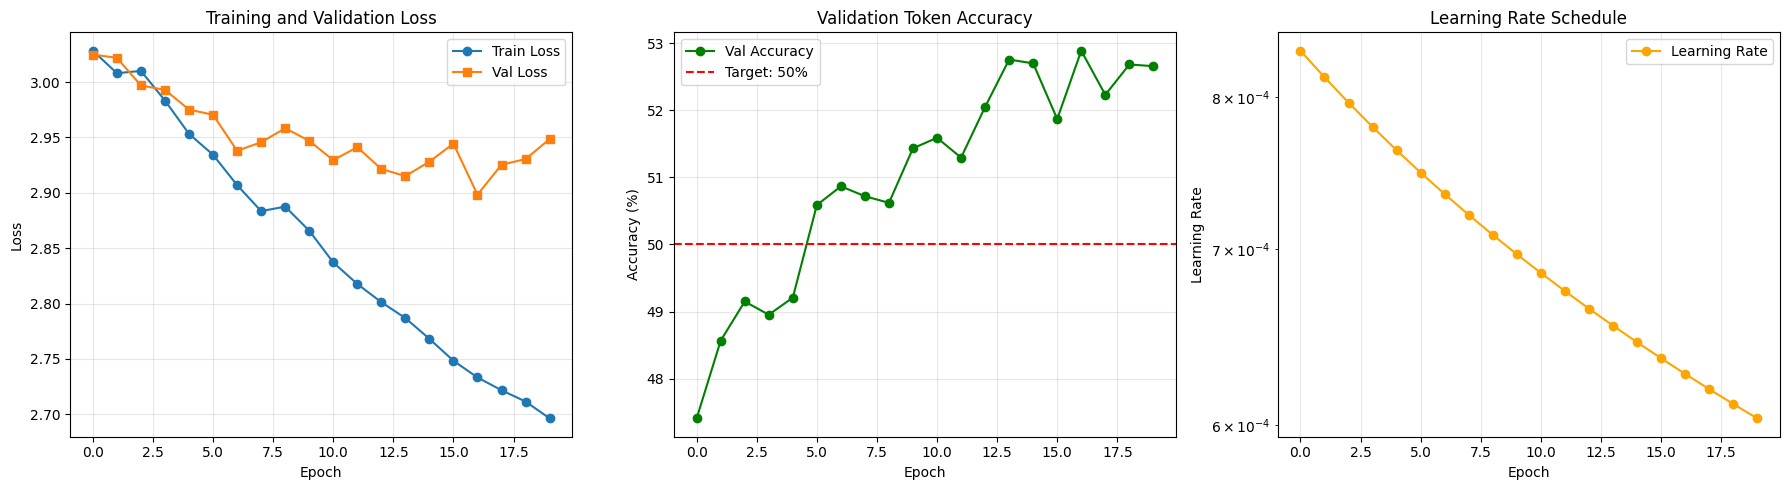

Final results:
  Train Loss: 2.6963
  Val Loss:   2.9485
  Val Acc:    52.66%
  Target Acc: >50% - ✓ ACHIEVED!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([acc * 100 for acc in val_accuracies], label='Val Accuracy', marker='o', color='green')
axes[1].axhline(y=50, color='red', linestyle='--', label='Target: 50%')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Token Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(learning_rates, label='Learning Rate', marker='o', color='orange')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final results:")
print(f"  Train Loss: {train_losses[-1]:.4f}")
print(f"  Val Loss:   {val_losses[-1]:.4f}")
print(f"  Val Acc:    {val_accuracies[-1]*100:.2f}%")
print(f"  Target Acc: >50% - {'✓ ACHIEVED!' if val_accuracies[-1] > 0.5 else '✗ NOT YET'}")

## 13. Загрузка лучшей модели и тестирование

In [ ]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model")
    print(f"Best validation loss: {best_val_loss:.4f}")
else:
    print("Using current model (no best saved)")


test_loss, test_accuracy, test_examples = validate(
    model, test_loader, criterion, device, tokenizer, max_samples=4
)

print(f"\nTest Results:")
print(f"  Test Loss:   {test_loss:.4f}")
print(f"  Test Acc:    {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print_examples(test_examples)

Loaded best model
Best validation loss: 2.8983


Validation: 100%|██████████| 47/47 [00:02<00:00, 22.66it/s]


Test Results:
  Test Loss:   2.9075
  Test Acc:    0.5362 (53.62%)

TRANSLATION EXAMPLES

--- Example 1 ---
Source (EN):      'Oh, it's a great undertaking!' said Sviyazhsky.
Target (RU):      -- О, капитальное дело!-- сказал Свияжский.
Prediction (RU):  -- Нет, постой. Он не поставиться. Он простить... простить?

--- Example 2 ---
Source (EN):      'Yes, she was bound to choose him.
Target (RU):      "Да, она должна была выбрать его.
Prediction (RU):  -- Нет, постой. Он не поставиться. Он простить? что? что?

--- Example 3 ---
Source (EN):      CHAPTER IV
Target (RU):      IV
Prediction (RU):  XXXIII  XXIII  XXIII  X XXIII X X X X X X X X X X X X X X X

--- Example 4 ---
Source (EN):      For the same reason as you.'
Target (RU):      Для того же, для чего и ты.
Prediction (RU):  Он посмотрел на не. Он пон понимает его. Он поедет. Она не



## 14. Примеры переводов на различных уровнях сложности

In [ ]:
# Составные примеры разной сложности
custom_examples = [
    # Простые (1 слово - 2 слова)
    {
        "source": "Hello",
        "complexity": "Very Simple"
    },
    {
        "source": "Good morning",
        "complexity": "Very Simple"
    },
    {
        "source": "Thank you",
        "complexity": "Very Simple"
    },
    {
        "source": "How are you?",
        "complexity": "Simple"
    },

    # Средние (короткие предложения)
    {
        "source": "I like to read books.",
        "complexity": "Medium"
    },
    {
        "source": "The weather is nice today.",
        "complexity": "Medium"
    },
    {
        "source": "She works at a hospital.",
        "complexity": "Medium"
    },
    {
        "source": "We went to the park yesterday.",
        "complexity": "Medium"
    },

    # Сложные (длинные предложения)
    {
        "source": "The quick brown fox jumps over the lazy dog.",
        "complexity": "Complex"
    },
    {
        "source": "Machine learning is a subset of artificial intelligence.",
        "complexity": "Complex"
    },
    {
        "source": "The scientist discovered a new method for solving this problem.",
        "complexity": "Complex"
    },
    {
        "source": "After finishing his work, he decided to take a short break.",
        "complexity": "Complex"
    },

    # Очень сложные (абстрактные или специальные)
    {
        "source": "The transformer architecture revolutionized the field of natural language processing.",
        "complexity": "Very Complex"
    },
    {
        "source": "The economic situation improved significantly after the new policy was implemented.",
        "complexity": "Very Complex"
    },
    {
        "source": "Advances in quantum computing may soon enable the solution of previously intractable problems.",
        "complexity": "Very Complex"
    },
    {
        "source": "The philosophical implications of artificial consciousness remain a subject of intense debate.",
        "complexity": "Very Complex"
    },

    # Разговорные/идиоматические
    {
        "source": "It's raining cats and dogs.",
        "complexity": "Idiomatic"
    },
    {
        "source": "Break a leg!",
        "complexity": "Idiomatic"
    },
    {
        "source": "I'm feeling under the weather today.",
        "complexity": "Idiomatic"
    },
]

def translate_text(model, tokenizer, text, device, max_length=128, beam_size=1):
    """Альтернативная версия с правильным преобразованием маски"""
    model.eval()

    with torch.no_grad():
        encoding = tokenizer(
            text,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        src_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        src_key_padding_mask = (attention_mask == 0).to(device)

        translated_ids = model.translate(
            src_ids,
            src_key_padding_mask=src_key_padding_mask,
            max_length=max_length
        )

        pred_ids = translated_ids[0]
        if len(pred_ids) > 0 and pred_ids[0] == config['bos_token_id']:
            pred_ids = pred_ids[1:]
        if len(pred_ids) > 0 and pred_ids[-1] == config['eos_token_id']:
            pred_ids = pred_ids[:-1]

        pred_ids = pred_ids[pred_ids != config['pad_token_id']]
        translated_text = tokenizer.decode(pred_ids, skip_special_tokens=True)

        return translated_text

print("\n" + "="*100)
print("CUSTOM EXAMPLES TRANSLATION")
print("="*100)

results = []
for example in custom_examples:
    try:
        translated = translate_text(
            model, tokenizer, example['source'], device,
            max_length=config['max_gen_length']
        )

        result = {
            'source': example['source'],
            'translation': translated,
            'complexity': example['complexity']
        }
        results.append(result)

        print(f"\n[{example['complexity']}]")
        print(f"Source (EN):     {example['source']}")
        print(f"Translation:    {translated}")

    except Exception as e:
        print(f"\n[ERROR] Failed to translate '{example['source']}': {e}")
        print(f"Error type: {type(e).__name__}")

print("\n" + "="*100)

print("\n" + "="*100)
print("TRANSLATION STATISTICS")
print("="*100)

from collections import Counter

complexity_stats = Counter()
for result in results:
    complexity_stats[result['complexity']] += 1

print(f"Total translations: {len(results)}")
print("\nTranslations by complexity:")
for complexity, count in complexity_stats.items():
    print(f"  {complexity}: {count}")

output_file = "translation_results.txt"
with open(output_file, 'w', encoding='utf-8') as f:
    f.write("="*100 + "\n")
    f.write("TRANSLATION RESULTS\n")
    f.write("="*100 + "\n\n")

    for i, result in enumerate(results, 1):
        f.write(f"[{i}] {result['complexity']}\n")
        f.write(f"Source (EN):     {result['source']}\n")
        f.write(f"Translation (RU): {result['translation']}\n")
        f.write("-"*100 + "\n\n")

    f.write("\n" + "="*100 + "\n")
    f.write(f"Total translations: {len(results)}\n")
    f.write("="*100 + "\n")

print(f"\nResults saved to '{output_file}'")


CUSTOM EXAMPLES TRANSLATION

[Very Simple]
Source (EN):     Hello
Translation:    Она подошела к нему.

[Very Simple]
Source (EN):     Good morning
Translation:    Он посмотрел на не.

[Very Simple]
Source (EN):     Thank you
Translation:    Она понимала его и портретила его руку.

[Simple]
Source (EN):     How are you?
Translation:    Нет, право ли?

[Medium]
Source (EN):     I like to read books.
Translation:    Она понимала его и не мог приехать его.

[Medium]
Source (EN):     The weather is nice today.
Translation:    Она понимала его и портретила его руку.

[Medium]
Source (EN):     She works at a hospital.
Translation:    Она подошела к нему.

[Medium]
Source (EN):     We went to the park yesterday.
Translation:    Она понимала его и портретила его руку.

[Complex]
Source (EN):     The quick brown fox jumps over the lazy dog.
Translation:    Она подошела к нему.

[Complex]
Source (EN):     Machine learning is a subset of artificial intelligence.
Translation:    Она понимала его 

## 15. Примеры из тестовой выборки

In [ ]:
print("\n" + "="*100)
print("TEST SET EXAMPLES (20 random samples)")
print("="*100)

test_results = []
indices = list(range(len(test_dataset)))
random.shuffle(indices)
selected_indices = indices[:20]

for i, idx in enumerate(selected_indices):
    sample = test_dataset[idx]

    translated = translate_text(
        model, tokenizer, sample['src_text'], device,
        max_length=config['max_gen_length'],
        beam_size=config['beam_size']
    )

    result = {
        'index': idx,
        'source': sample['src_text'],
        'target': sample['tgt_text'],
        'translation': translated
    }
    test_results.append(result)

    print(f"\n--- Test Example {i+1} ---")
    print(f"Source (EN):     {sample['src_text']}")
    print(f"Target (RU):     {sample['tgt_text']}")
    print(f"Translation:    {translated}")

print("\n" + "="*100)


TEST SET EXAMPLES (20 random samples)

--- Test Example 1 ---
Source (EN):     Everybody laughed, and Oblonsky most merrily of all.
Target (RU):     Все засмеялись, и в особенности весело Степан Аркадьич.
Translation:    Она понимала его и портретила его руку.

--- Test Example 2 ---
Source (EN):     I am pained too because this breaks our friendship.
Target (RU):     Мне больно еще то, что это разрывает нашу дружбу.
Translation:    Он посмотрел на не.

--- Test Example 3 ---
Source (EN):     I can't do anything, begin anything, change anything!
Target (RU):     А я не могу писать еще.
Translation:    Нет, право ли?

--- Test Example 4 ---
Source (EN):     'Yes, he is kind to me, but...'
Target (RU):     -- Да, он ко мне добр, но...
Translation:    -- Нет, постой.

--- Test Example 5 ---
Source (EN):     Or was it a dream?
Target (RU):     Или я во сне видел?
Translation:    Он посмотрел на не.

--- Test Example 6 ---
Source (EN):     'On the contrary!
Target (RU):     -- Напротив!
Tr

## 16. Сохранение модели

In [ ]:
# Сохраняем модель
model_path = 'transformer_translation_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_accuracies': val_accuracies,
    'learning_rates': learning_rates,
    'best_val_loss': best_val_loss,
    'final_accuracy': test_accuracy
}, model_path)

print(f"Model saved to {model_path}")

# Сохраняем результаты переводов в текстовый файл
with open('translation_results.txt', 'w', encoding='utf-8') as f:
    f.write("="*100 + "\n")
    f.write("TRANSFORMER MACHINE TRANSLATION RESULTS\n")
    f.write("="*100 + "\n\n")

    f.write("Model Configuration:\n")
    for k, v in config.items():
        f.write(f"  {k}: {v}\n")
    f.write("\n")

    f.write("Training Results:\n")
    f.write(f"  Final Train Loss: {train_losses[-1]:.4f}\n")
    f.write(f"  Final Val Loss:   {val_losses[-1]:.4f}\n")
    f.write(f"  Best Val Loss:    {best_val_loss:.4f}\n")
    f.write(f"  Test Accuracy:    {test_accuracy*100:.2f}%\n\n")

    f.write("-"*100 + "\n")
    f.write("CUSTOM EXAMPLES\n")
    f.write("-"*100 + "\n\n")

    for i, r in enumerate(results):
        f.write(f"Example {i+1} [{r['complexity']}]:\n")
        f.write(f"  Source:     {r['source']}\n")
        f.write(f"  Translation: {r['translation']}\n\n")

    f.write("-"*100 + "\n")
    f.write("TEST SET EXAMPLES (20 samples)\n")
    f.write("-"*100 + "\n\n")

    for i, r in enumerate(test_results):
        f.write(f"Test Example {i+1}:\n")
        f.write(f"  Source:     {r['source']}\n")
        f.write(f"  Target:     {r['target']}\n")
        f.write(f"  Translation: {r['translation']}\n\n")

print("Results saved to translation_results.txt")

Model saved to transformer_translation_model.pth
Results saved to translation_results.txt


## 17. Функция для загрузки и использования модели

In [ ]:
def load_model_for_inference(model_path, tokenizer, device):
    """Загружает обученную модель для инференса"""
    checkpoint = torch.load(model_path, map_location=device)

    config_loaded = checkpoint['config']
    model = TransformerTranslationModel(config_loaded, tokenizer).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    return model, config_loaded

def translate_new_text(text, model, tokenizer, device, max_length=128, beam_size=1):
    """Переводит новый текст"""
    return translate_text(model, tokenizer, text, device, max_length, beam_size)

model, config = load_model_for_inference('transformer_translation_model.pth', tokenizer, device)